# Thực nghiệm so sánh Bloom Filter và Counting Bloom Filter

Notebook này cài đặt từ đầu **Bloom Filter (BF)** và **Counting Bloom Filter (CBF)**, rồi chạy 4 thực nghiệm định lượng phục vụ báo cáo *"So sánh Bloom Filter và Counting Bloom Filter trong bài toán lọc dữ liệu tốc độ cao"* (`report.tex`):

| Thực nghiệm | Câu hỏi | Giả thuyết |
|---|---|---|
| **E1** | FPR thực nghiệm có bám công thức lý thuyết? Thông lượng insert/query/delete? | H1, H3 |
| **E2** | FPR theo số hàm băm $k$ — cực tiểu có đúng tại $k^*=(m/n)\ln 2$? | H4 |
| **E3** | Cùng ngân sách **byte**, BF hay CBF chính xác hơn? | H2 |
| **E4** | Xóa phần tử bị nhận nhầm (false positive) gây false negative ra sao? | — |

**Yêu cầu gói:** `pip install mmh3 bitarray numpy pandas matplotlib jinja2`

> Notebook **tự chứa** và là **nguồn duy nhất** của thực nghiệm: chạy toàn bộ notebook sẽ tái sinh `fig/*.png`, `tab/*.tex` (bảng + macro số liệu) và `results.json` mà `report.tex` nhúng vào. Khóa sinh tất định nên FPR tái lập được 100%; số đo thông lượng thay đổi nhẹ theo máy.

## 1. Tóm tắt lý thuyết

- **BF** (Bloom, 1970): mảng $m$ bit, $k$ hàm băm. Insert bật bit, Query kiểm tra đủ $k$ bit. Không false negative, không xóa được.
- **CBF** (Fan *et al.*, 2000): thay bit bằng counter $b$ bit (thường $b=4$, bão hòa ở 15) → xóa được, đổi lại tốn $b\times$ bộ nhớ và có thể sinh false negative khi xóa sai.

Các công thức dùng để đối chiếu:

$$p \approx \left(1-e^{-kn/m}\right)^k, \qquad k^* = \frac{m}{n}\ln 2, \qquad m = -\frac{n\ln p}{(\ln 2)^2}$$

Số phần tử băm vào một counter $\approx$ Poisson$(\lambda{=}\ln 2)$ ở cấu hình tối ưu, nên $\Pr[\text{counter} = 16] \approx 6{.}78\times 10^{-17}$ — vì vậy 4 bit/counter là đủ (Fan *et al.* 2000).

**Lưu ý then chốt:** với *cùng* $m$, $k$ và cùng bộ hàm băm, CBF (chỉ chèn) trả lời truy vấn **giống hệt** BF từng khóa — khác biệt thật sự nằm ở bộ nhớ và khả năng xóa.

In [1]:
import math
import os
import time

import mmh3                      # MurmurHash3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bitarray import bitarray

os.makedirs("fig", exist_ok=True)   # hinh cho report.tex
os.makedirs("tab", exist_ok=True)   # bang + macro so lieu cho report.tex
T0 = time.perf_counter()            # tinh tong thoi gian thuc nghiem

# ---- bang mau nhat quan, than thien voi nguoi mu mau ----
INK, SEC, MUT = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
C_BF, C_CBF4, C_CBF8 = "#2a78d6", "#eb6834", "#1baf7a"   # mau theo cau truc
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5, "font.family": "DejaVu Sans",
    "axes.edgecolor": AXIS, "axes.labelcolor": SEC, "text.color": INK,
    "xtick.color": MUT, "ytick.color": MUT,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False,
})


def optimal_k(m: int, n: int) -> int:
    """So ham bam toi uu k = (m/n) ln 2 (lam tron, toi thieu 1)."""
    return max(1, int(round((m / n) * math.log(2))))


def theoretical_fpr(m: int, n: int, k: int) -> float:
    """FPR ly thuyet p = (1 - e^{-kn/m})^k."""
    return (1.0 - math.exp(-k * n / m)) ** k


def _positions(key: str, k: int, m: int):
    """k vi tri bang double hashing Kirsch-Mitzenmacher tu 2 seed MurmurHash3."""
    h1 = mmh3.hash(key, 0, signed=False)
    h2 = mmh3.hash(key, 1, signed=False) | 1   # tranh h2 = 0 (chu ky suy bien)
    for i in range(k):
        yield (h1 + i * h2) % m


class BloomFilter:
    def __init__(self, m: int, k: int):
        self.m, self.k = m, k
        self.bits = bitarray(m)
        self.bits.setall(0)

    def insert(self, key):
        for pos in _positions(key, self.k, self.m):
            self.bits[pos] = 1

    def query(self, key):
        return all(self.bits[pos] for pos in _positions(key, self.k, self.m))

    def fill_ratio(self):
        return self.bits.count() / self.m

    def memory_bytes(self):
        return (self.m + 7) // 8


class CountingBloomFilter8:
    """CBF voi counter 4-bit luu bang 1 byte (don gian, ton 8 bit/o)."""
    MAX = 15

    def __init__(self, m: int, k: int):
        self.m, self.k = m, k
        self.counts = bytearray(m)

    def insert(self, key):
        for pos in _positions(key, self.k, self.m):
            if self.counts[pos] < self.MAX:
                self.counts[pos] += 1

    def query(self, key):
        return all(self.counts[pos] > 0 for pos in _positions(key, self.k, self.m))

    def delete(self, key):
        """Xoa co kiem tra; tra ve True neu phep xoa thuc su duoc thuc hien."""
        if not self.query(key):
            return False
        for pos in _positions(key, self.k, self.m):
            if 0 < self.counts[pos] < self.MAX:   # khong giam counter da bao hoa
                self.counts[pos] -= 1
        return True

    def memory_bytes(self):
        return self.m


class CountingBloomFilter4:
    """CBF 4-bit dung nghia: 2 counter/byte (nibble packing) -> dung 4x BF."""
    MAX = 15

    def __init__(self, m: int, k: int):
        self.m, self.k = m, k
        self.buf = bytearray((m + 1) // 2)

    def _get(self, i):
        b = self.buf[i >> 1]
        return (b >> 4) if (i & 1) else (b & 0x0F)

    def _set(self, i, v):
        j = i >> 1
        if i & 1:
            self.buf[j] = (self.buf[j] & 0x0F) | (v << 4)
        else:
            self.buf[j] = (self.buf[j] & 0xF0) | v

    def insert(self, key):
        for pos in _positions(key, self.k, self.m):
            v = self._get(pos)
            if v < self.MAX:
                self._set(pos, v + 1)

    def query(self, key):
        return all(self._get(pos) > 0 for pos in _positions(key, self.k, self.m))

    def delete(self, key):
        if not self.query(key):
            return False
        for pos in _positions(key, self.k, self.m):
            v = self._get(pos)
            if 0 < v < self.MAX:
                self._set(pos, v - 1)
        return True

    def memory_bytes(self):
        return (self.m + 1) // 2

print("Đã định nghĩa BloomFilter, CountingBloomFilter4 (nibble), CountingBloomFilter8 (byte).")

Đã định nghĩa BloomFilter, CountingBloomFilter4 (nibble), CountingBloomFilter8 (byte).


## 2. Dữ liệu và hàm đo

Khóa sinh **tất định** (`P000000000…` cho tập đã chèn, `A000000000…` cho tập vắng mặt) để kết quả FPR tái lập được. FPR đo bằng tỉ lệ khóa vắng mặt bị trả lời "có"; thông lượng đo bằng `time.perf_counter` trên toàn bộ $n$ thao tác (query lặp 2 lượt lấy lượt tốt nhất).

In [2]:
N = 100_000
RATIOS = (4, 6, 8, 10, 12, 16)
PRESENT = [f"P{i:09d}" for i in range(N)]   # khoa se duoc chen
ABSENT  = [f"A{i:09d}" for i in range(N)]   # khoa chua tung chen


def timed(fn, keys, repeat=1):
    """Thong luong ops/s (lay lan chay tot nhat trong `repeat` lan)."""
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        for key in keys:
            fn(key)
        best = min(best, time.perf_counter() - t0)
    return len(keys) / best


def measure_fpr(f, absent_keys):
    return sum(1 for key in absent_keys if f.query(key)) / len(absent_keys)


# --- smoke test nhanh ---
_bf, _c4 = BloomFilter(80_000, 6), CountingBloomFilter4(80_000, 6)
for x in PRESENT[:10_000]:
    _bf.insert(x); _c4.insert(x)
assert all(_bf.query(x) for x in PRESENT[:10_000]), "BF khong duoc phep co false negative"
assert all(_c4.query(x) for x in PRESENT[:10_000])
assert measure_fpr(_bf, ABSENT[:10_000]) == measure_fpr(_c4, ABSENT[:10_000]), \
    "cung m, k, cung ham bam -> BF va CBF phai tra loi giong het nhau"
for x in PRESENT[:10_000]:
    _c4.delete(x)
assert sum(_c4.query(x) for x in PRESENT[:10_000]) == 0, "xoa het thi CBF phai rong"
print("Smoke test OK: không FN khi chỉ chèn; BF ≡ CBF cùng cấu hình; delete hoạt động đúng.")

Smoke test OK: không FN khi chỉ chèn; BF ≡ CBF cùng cấu hình; delete hoạt động đúng.


## 3. E1 — FPR và thông lượng theo $m/n$ (H1, H3)

Với mỗi tỉ lệ $m/n$, chèn $n$ khóa vào cả ba cấu trúc với $k=\mathrm{round}((m/n)\ln 2)$, đo FPR trên $n$ khóa vắng mặt và thông lượng từng thao tác. Câu trả lời của BF và CBF được **assert trùng nhau trên từng khóa** — minh họa rằng CBF không "chính xác hơn" BF.

In [3]:
rows = []
for r in RATIOS:
    m, k = r * N, optimal_k(r * N, N)
    bf, c4, c8 = BloomFilter(m, k), CountingBloomFilter4(m, k), CountingBloomFilter8(m, k)

    ins_bf, ins_c4, ins_c8 = timed(bf.insert, PRESENT), timed(c4.insert, PRESENT), timed(c8.insert, PRESENT)

    fpr_bf, fpr_c4 = measure_fpr(bf, ABSENT), measure_fpr(c4, ABSENT)
    # cung vi tri bam -> cau tra loi phai trung nhau TUNG khoa (khong chi FPR gop)
    assert all(bf.query(x) == c4.query(x) for x in ABSENT)

    qmiss_bf = timed(bf.query, ABSENT, repeat=2)
    qmiss_c4 = timed(c4.query, ABSENT, repeat=2)
    qmiss_c8 = timed(c8.query, ABSENT, repeat=2)
    qhit_bf  = timed(bf.query, PRESENT, repeat=2)
    qhit_c4  = timed(c4.query, PRESENT, repeat=2)
    del_c4, del_c8 = timed(c4.delete, PRESENT), timed(c8.delete, PRESENT)
    leftover = sum(1 for x in PRESENT if c4.query(x))   # sau khi xoa het -> ky vong 0

    rows.append(dict(ratio=r, k=k, fpr_theory=theoretical_fpr(m, N, k),
                     fpr_emp=fpr_bf, fill_bf=bf.fill_ratio(),
                     fill_theory=1 - math.exp(-k * N / m),
                     mem_bf=bf.memory_bytes(), mem_c4=c4.memory_bytes(), mem_c8=c8.memory_bytes(),
                     ins_bf=ins_bf, ins_c4=ins_c4, ins_c8=ins_c8,
                     qmiss_bf=qmiss_bf, qmiss_c4=qmiss_c4, qmiss_c8=qmiss_c8,
                     qhit_bf=qhit_bf, qhit_c4=qhit_c4,
                     del_c4=del_c4, del_c8=del_c8, leftover=leftover))
    print(f"m/n={r:>2} k={k:>2}: FPR lý thuyết={rows[-1]['fpr_theory']:.5f}, "
          f"đo được={fpr_bf:.5f}, còn sót sau xóa hết={leftover}")

e1 = pd.DataFrame(rows)
display(e1[["ratio", "k", "fpr_theory", "fpr_emp", "fill_bf", "fill_theory"]]
        .rename(columns={"ratio": "m/n", "fpr_theory": "FPR lý thuyết",
                         "fpr_emp": "FPR đo được (BF ≡ CBF)",
                         "fill_bf": "tỉ lệ bit 1 (đo)", "fill_theory": "tỉ lệ bit 1 (lt)"})
        .style.format({"FPR lý thuyết": "{:.5f}", "FPR đo được (BF ≡ CBF)": "{:.5f}",
                       "tỉ lệ bit 1 (đo)": "{:.3f}", "tỉ lệ bit 1 (lt)": "{:.3f}"}))

m/n= 4 k= 3: FPR lý thuyết=0.14689, đo được=0.14933, còn sót sau xóa hết=0


m/n= 6 k= 4: FPR lý thuyết=0.05606, đo được=0.05650, còn sót sau xóa hết=0


m/n= 8 k= 6: FPR lý thuyết=0.02158, đo được=0.02164, còn sót sau xóa hết=0


m/n=10 k= 7: FPR lý thuyết=0.00819, đo được=0.00819, còn sót sau xóa hết=0


m/n=12 k= 8: FPR lý thuyết=0.00314, đo được=0.00334, còn sót sau xóa hết=0


m/n=16 k=11: FPR lý thuyết=0.00046, đo được=0.00043, còn sót sau xóa hết=0


,m/n,k,FPR lý thuyết,FPR đo được (BF ≡ CBF),tỉ lệ bit 1 (đo),tỉ lệ bit 1 (lt)
0,4,3,0.14689,0.14933,0.529,0.528
1,6,4,0.05606,0.05650,0.487,0.487
2,8,6,0.02158,0.02164,0.528,0.528
3,10,7,0.00819,0.00819,0.503,0.503
4,12,8,0.00314,0.00334,0.487,0.487
5,16,11,0.00046,0.00043,0.497,0.497


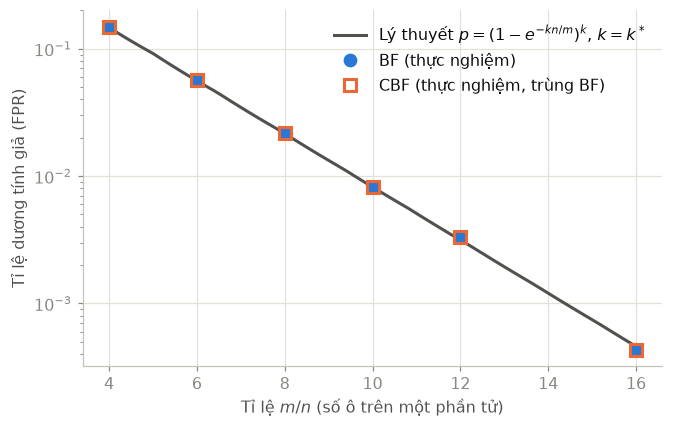

In [4]:
fine = np.arange(4, 16.01, 0.2)
th = [theoretical_fpr(int(x * N), N, optimal_k(int(x * N), N)) for x in fine]
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(fine, th, "-", color=SEC, lw=2, label="Lý thuyết $p=(1-e^{-kn/m})^k$, $k=k^*$")
ax.plot(e1["ratio"], e1["fpr_emp"], "o", color=C_BF, ms=8, label="BF (thực nghiệm)")
ax.plot(e1["ratio"], e1["fpr_emp"], "s", color=C_CBF4, ms=8, mfc="none", mew=2,
        label="CBF (thực nghiệm, trùng BF)")
ax.set_yscale("log")
ax.set_xlabel("Tỉ lệ $m/n$ (số ô trên một phần tử)")
ax.set_ylabel("Tỉ lệ dương tính giả (FPR)")
ax.legend()
fig.savefig("fig/fpr_vs_mn.png", dpi=200, bbox_inches="tight")
plt.show()

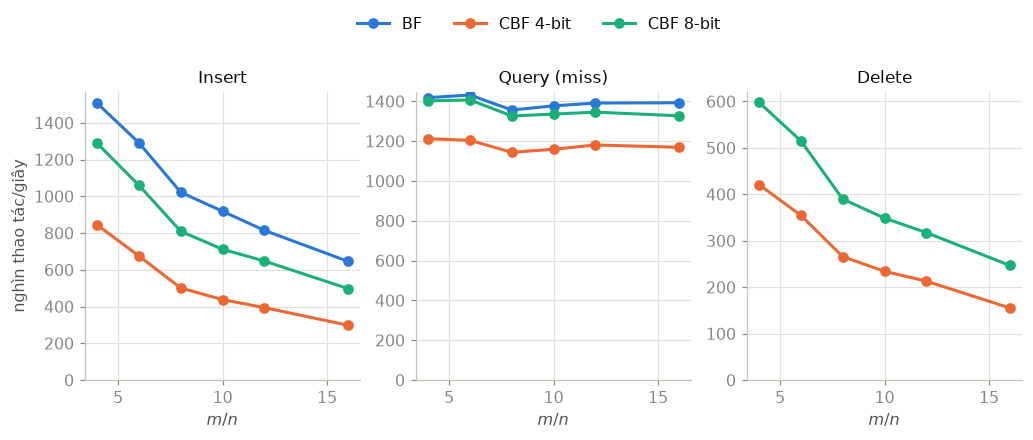

Tại m/n=10: insert BF nhanh gấp 2.10 lần CBF 4-bit; query(miss) gấp 1.19 lần; delete CBF 4-bit chỉ đạt 234 nghìn thao tác/giây.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharex=True)
panels = [("Insert", [("BF", "ins_bf", C_BF), ("CBF 4-bit", "ins_c4", C_CBF4),
                      ("CBF 8-bit", "ins_c8", C_CBF8)]),
          ("Query (miss)", [("BF", "qmiss_bf", C_BF), ("CBF 4-bit", "qmiss_c4", C_CBF4),
                            ("CBF 8-bit", "qmiss_c8", C_CBF8)]),
          ("Delete", [("CBF 4-bit", "del_c4", C_CBF4), ("CBF 8-bit", "del_c8", C_CBF8)])]
for ax, (title, series) in zip(axes, panels):
    for label, field, color in series:
        ax.plot(e1["ratio"], e1[field] / 1e3, "o-", color=color, lw=2, ms=6, label=label)
    ax.set_title(title, color=INK, fontsize=11)
    ax.set_xlabel("$m/n$")
    ax.set_ylim(bottom=0)
axes[0].set_ylabel("nghìn thao tác/giây")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.12))
fig.savefig("fig/throughput.png", dpi=200, bbox_inches="tight")
plt.show()

r10 = e1.set_index("ratio").loc[10]
print(f"Tại m/n=10: insert BF nhanh gấp {r10.ins_bf / r10.ins_c4:.2f} lần CBF 4-bit; "
      f"query(miss) gấp {r10.qmiss_bf / r10.qmiss_c4:.2f} lần; "
      f"delete CBF 4-bit chỉ đạt {r10.del_c4 / 1e3:.0f} nghìn thao tác/giây.")

**Nhận xét E1.** FPR đo được bám sát lý thuyết trên toàn dải (H1 ✓); tỉ lệ bit 1 xấp xỉ $1/2$ đúng như phân tích entropy. BF nhanh hơn CBF ở mọi thao tác vì chỉ bật/đọc bit thay vì đọc–sửa–ghi counter (H3 ✓); CBF 8-bit nhanh hơn CBF 4-bit một chút do không phải tách nibble — đánh đổi tốc độ/bộ nhớ ngay trong nội bộ CBF. Delete đắt nhất vì gồm một lượt query đầy đủ cộng $k$ lần đọc–sửa–ghi. Số tuyệt đối phản ánh chi phí Python; điều có ý nghĩa là **tỉ số tương đối**.

## 4. E2 — FPR theo số hàm băm $k$ (H4)

Cố định $m/n=10$, quét $k$ từ 1 đến 12. Kỳ vọng cực tiểu tại $k^*=(m/n)\ln 2\approx 7$: $k$ nhỏ → mỗi phép thử dễ trùng; $k$ lớn → mảng bit bị lấp đầy.

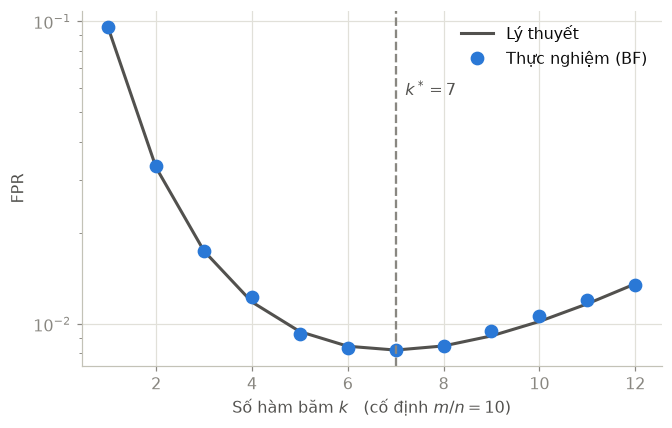

FPR nhỏ nhất đo được tại k=7 (lý thuyết k*=7): 0.00819


In [6]:
m10 = 10 * N
ks = list(range(1, 13))
fpr_th_k, fpr_emp_k = [], []
for k in ks:
    bf = BloomFilter(m10, k)
    for x in PRESENT:
        bf.insert(x)
    fpr_th_k.append(theoretical_fpr(m10, N, k))
    fpr_emp_k.append(measure_fpr(bf, ABSENT))

k_opt = optimal_k(m10, N)
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(ks, fpr_th_k, "-", color=SEC, lw=2, label="Lý thuyết")
ax.plot(ks, fpr_emp_k, "o", color=C_BF, ms=8, label="Thực nghiệm (BF)")
ax.axvline(k_opt, color=MUT, ls="--", lw=1.5)
ax.annotate(f"$k^*={k_opt}$", xy=(k_opt + 0.2, max(fpr_th_k) * 0.6), color=SEC)
ax.set_yscale("log")
ax.set_xlabel("Số hàm băm $k$   (cố định $m/n=10$)")
ax.set_ylabel("FPR")
ax.legend()
fig.savefig("fig/fpr_vs_k.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"FPR nhỏ nhất đo được tại k={ks[int(np.argmin(fpr_emp_k))]} "
      f"(lý thuyết k*={k_opt}): {min(fpr_emp_k):.5f}")

## 5. E3 — Cùng ngân sách bộ nhớ: BF hay CBF chính xác hơn? (H2)

Đây là phép so công bằng khi bộ nhớ là ràng buộc cứng: cùng $B$ byte thì BF có $8B$ ô, CBF 4-bit có $2B$ ô, CBF 8-bit có $B$ ô (mỗi cấu trúc dùng $k$ tối ưu của riêng nó). Chọn $B$ = bộ nhớ của BF tại $m/n=10$.

,cấu_trúc,số_ô,k,mem_byte,FPR_lý_thuyết,FPR_đo_được
0,BF,"1,000,000",7,"125,000",0.0082,0.0082
1,CBF 4-bit,"250,000",2,"125,000",0.3032,0.3009
2,CBF 8-bit,"125,000",1,"125,000",0.5507,0.5494


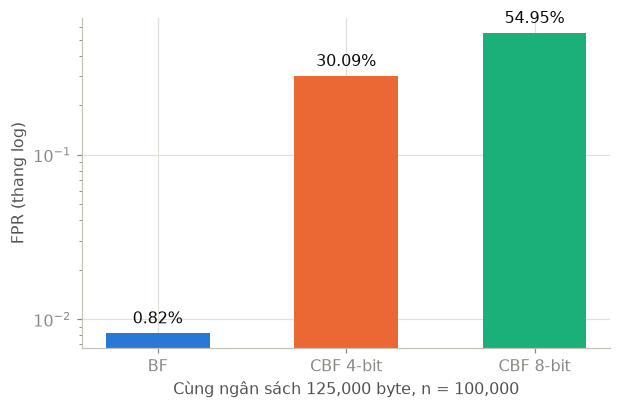

In [7]:
budget = 10 * N // 8          # 125 000 byte
cfgs = []
for name, cls, cells_ in (("BF", BloomFilter, budget * 8),
                          ("CBF 4-bit", CountingBloomFilter4, budget * 2),
                          ("CBF 8-bit", CountingBloomFilter8, budget)):
    k = optimal_k(cells_, N)
    f = cls(cells_, k)
    for x in PRESENT:
        f.insert(x)
    cfgs.append(dict(cấu_trúc=name, số_ô=cells_, k=k, mem_byte=f.memory_bytes(),
                     FPR_lý_thuyết=theoretical_fpr(cells_, N, k),
                     FPR_đo_được=measure_fpr(f, ABSENT)))
e3 = pd.DataFrame(cfgs)
display(e3.style.format({"FPR_lý_thuyết": "{:.4f}", "FPR_đo_được": "{:.4f}",
                         "số_ô": "{:,}", "mem_byte": "{:,}"}))

fig, ax = plt.subplots(figsize=(6.2, 3.9))
bars = ax.bar(e3["cấu_trúc"], e3["FPR_đo_được"], color=[C_BF, C_CBF4, C_CBF8], width=0.55)
for bar, v in zip(bars, e3["FPR_đo_được"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.15, f"{100 * v:.2f}%",
            ha="center", color=INK)
ax.set_yscale("log")
ax.set_ylabel("FPR (thang log)")
ax.set_xlabel(f"Cùng ngân sách {budget:,} byte, n = {N:,}")
fig.savefig("fig/equal_budget.png", dpi=200, bbox_inches="tight")
plt.show()

**Nhận xét E3.** Cùng một lượng byte, FPR của CBF 4-bit cao hơn BF khoảng **hai bậc độ lớn** (H2 ✓). Đây chính là cái giá thật của khả năng xóa: mỗi bit thông tin của CBF đắt gấp 4 lần, nên chỉ trả giá này khi *bắt buộc* phải xóa động mà không thể rebuild định kỳ.

## 6. E4 — Xóa sai gây false negative trong CBF

Kịch bản thực tế: hệ thống tin câu trả lời "có" của CBF và xóa một khóa **chưa từng được chèn** (false positive). Mỗi lần xóa như vậy giảm nhầm $k$ counter mà các phần tử thật đang dùng chung → phần tử thật "biến mất". Lưu ý phép xóa có kiểm tra (query trước), nên một phần khóa FP về sau bị chặn nhờ các lần xóa trước đã hạ counter.

In [8]:
m8, k8 = 8 * N, optimal_k(8 * N, N)
cbf = CountingBloomFilter4(m8, k8)
for x in PRESENT:
    cbf.insert(x)

fp_keys = [x for x in ABSENT if cbf.query(x)]        # khoa vang mat bi bao nham "co"
performed = sum(1 for x in fp_keys if cbf.delete(x)) # so lan xoa thuc su thuc hien
false_neg = sum(1 for x in PRESENT if not cbf.query(x))

print(f"Cấu hình m/n=8, k={k8}, n={N:,}")
print(f"Khóa vắng mặt bị báo nhầm 'có' (false positive): {len(fp_keys):,}")
print(f"Lần xóa thực sự thực hiện (delete có kiểm tra) : {performed:,}")
print(f"Phần tử thật bị mất (FALSE NEGATIVE)           : {false_neg:,} "
      f"({100 * false_neg / N:.3f}% của {N:,})")
print(f"\n=> Chỉ {len(fp_keys):,} lần xóa sai đã làm mất {false_neg:,} phần tử thật —")
print("   BF không bao giờ mắc lỗi này vì không có thao tác xóa.")

Cấu hình m/n=8, k=6, n=100,000
Khóa vắng mặt bị báo nhầm 'có' (false positive): 2,164
Lần xóa thực sự thực hiện (delete có kiểm tra) : 2,041
Phần tử thật bị mất (FALSE NEGATIVE)           : 8,063 (8.063% của 100,000)

=> Chỉ 2,164 lần xóa sai đã làm mất 8,063 phần tử thật —
   BF không bao giờ mắc lỗi này vì không có thao tác xóa.


## 7. Kết luận

| Giả thuyết | Kết quả |
|---|---|
| **H1** — FPR thực nghiệm trùng giữa BF/CBF và bám lý thuyết | ✓ (trùng *từng khóa*, sai lệch với lý thuyết trong biên độ thống kê) |
| **H2** — CBF 4-bit tốn $4\times$ bộ nhớ BF (8-bit: $8\times$) | ✓ (đo chính xác 4.0× / 8.0×; cùng ngân sách byte thì FPR chênh ~2 bậc độ lớn) |
| **H3** — BF nhanh hơn CBF; delete là thao tác đắt riêng của CBF | ✓ với CBF 4-bit ở mọi thao tác; CBF 8-bit bám sát BF ở query nhưng chậm hơn ở insert |
| **H4** — FPR giảm mũ theo $m/n$, cực tiểu theo $k$ tại $k^*$ | ✓ ($k^*=7$ tại $m/n=10$) |

**Khuyến nghị:** dùng **BF** cho tập gần như tĩnh hoặc rebuild được định kỳ; chỉ dùng **CBF 4-bit** khi bắt buộc xóa động (kèm lịch rebuild để triệt tích lũy false negative); khi cần xóa với FPR mục tiêu $<3\%$, cân nhắc **Cuckoo Filter**. Chi tiết lý thuyết, trích dẫn và thảo luận đầy đủ: xem `report.pdf`.

## 8. Phụ lục — Xuất số liệu cho báo cáo LaTeX

Cell dưới ghi toàn bộ sản phẩm số liệu mà `report.tex` nhúng: các mảnh bảng `booktabs` trong `tab/`, macro số liệu `tab/numbers.tex` (để lời văn của báo cáo không phải chép số tay), và `results.json` (bản ghi đầy đủ). Bốn hình trong `fig/` đã được lưu ngay tại cell vẽ của từng thực nghiệm. Sau khi chạy notebook, biên dịch lại báo cáo bằng `pdflatex report.tex` (2 lượt).

In [9]:
import json
import platform


def sep(x):
    """So nguyen kieu SI: dau cach manh \\, lam phan cach hang nghin (LaTeX)."""
    return f"{x:,.0f}".replace(",", "\\,")


def fmt_pct(x):
    return f"{100 * x:.3f}\\%" if x < 0.10 else f"{100 * x:.1f}\\%"


def pct(x, d=2):
    return f"{100 * x:.{d}f}\\%"


def kops(x):
    return sep(x / 1e3)


# ---- tab/fpr.tex : E1, FPR ly thuyet vs thuc nghiem ----
with open("tab/fpr.tex", "w") as f:
    f.write("\\begin{tabular}{@{}rrrrrrr@{}}\n\\toprule\n"
            "$m/n$ & $k$ & FPR lý thuyết & FPR BF & FPR CBF & "
            "Tỉ lệ bit 1 (đo) & (lý thuyết)\\\\\n\\midrule\n")
    for r in e1.itertuples():
        f.write(f"{r.ratio} & {r.k} & {fmt_pct(r.fpr_theory)} & "
                f"{fmt_pct(r.fpr_emp)} & {fmt_pct(r.fpr_emp)} & "
                f"{r.fill_bf:.3f} & {r.fill_theory:.3f}\\\\\n")
    f.write("\\bottomrule\n\\end{tabular}\n")

# ---- tab/throughput.tex : E1, thong luong ----
with open("tab/throughput.tex", "w") as f:
    f.write("\\begin{tabular}{@{}rrrrrrrr@{}}\n\\toprule\n"
            "$m/n$ & $k$ & \\multicolumn{2}{c}{Insert} & "
            "\\multicolumn{2}{c}{Query (miss)} & "
            "\\multicolumn{2}{c}{Query (hit) / Delete}\\\\\n"
            "\\cmidrule(lr){3-4}\\cmidrule(lr){5-6}\\cmidrule(l){7-8}\n"
            " & & BF & CBF4 & BF & CBF4 & BF hit & CBF4 del\\\\\n\\midrule\n")
    for r in e1.itertuples():
        f.write(f"{r.ratio} & {r.k} & {kops(r.ins_bf)} & {kops(r.ins_c4)} & "
                f"{kops(r.qmiss_bf)} & {kops(r.qmiss_c4)} & "
                f"{kops(r.qhit_bf)} & {kops(r.del_c4)}\\\\\n")
    f.write("\\bottomrule\n\\end{tabular}\n")

# ---- tab/memory.tex : E1, bo nho ----
with open("tab/memory.tex", "w") as f:
    f.write("\\begin{tabular}{@{}rrrrrr@{}}\n\\toprule\n"
            "$m/n$ & $m$ (ô) & BF (byte) & CBF 4-bit (byte) & CBF 8-bit (byte) & "
            "CBF4/BF\\\\\n\\midrule\n")
    for r in e1.itertuples():
        f.write(f"{r.ratio} & {sep(r.ratio * N)} & {sep(r.mem_bf)} & "
                f"{sep(r.mem_c4)} & {sep(r.mem_c8)} & "
                f"{r.mem_c4 / r.mem_bf:.1f}$\\times$\\\\\n")
    f.write("\\bottomrule\n\\end{tabular}\n")

# ---- tab/equal_budget.tex : E3 ----
bits = {"BF": 1, "CBF 4-bit": 4, "CBF 8-bit": 8}
with open("tab/equal_budget.tex", "w") as f:
    f.write("\\begin{tabular}{@{}lrrrrr@{}}\n\\toprule\n"
            "Cấu trúc & Số ô & bit/ô & $k$ & FPR lý thuyết & FPR thực nghiệm\\\\\n"
            "\\midrule\n")
    for _, c in e3.iterrows():
        f.write(f"{c['cấu_trúc']} & {sep(c['số_ô'])} & {bits[c['cấu_trúc']]} & "
                f"{c['k']} & {fmt_pct(c['FPR_lý_thuyết'])} & "
                f"{fmt_pct(c['FPR_đo_được'])}\\\\\n")
    f.write("\\bottomrule\n\\end{tabular}\n")

# ---- tab/false_neg.tex : E4 ----
with open("tab/false_neg.tex", "w") as f:
    f.write("\\begin{tabular}{@{}lr@{}}\n\\toprule\nĐại lượng & Giá trị\\\\\n\\midrule\n"
            f"Cấu hình & $m/n={m8 // N}$, $k={k8}$, $n={sep(N)}$\\\\\n"
            f"Khóa vắng mặt bị báo nhầm ``có'' (false positive) & {sep(len(fp_keys))}\\\\\n"
            f"Lần xóa thực sự thực hiện (delete có kiểm tra) & {sep(performed)}\\\\\n"
            f"Phần tử thật bị mất (false negative) & {sep(false_neg)}\\\\\n"
            f"Tỉ lệ false negative & {fmt_pct(false_neg / N)}\\\\\n"
            "\\bottomrule\n\\end{tabular}\n")

# ---- tab/numbers.tex : macro so lieu cho loi van bao cao ----
cpu = platform.processor() or "unknown"
try:
    with open("/proc/cpuinfo") as f:
        for line in f:
            if line.startswith("model name"):
                cpu = line.split(":", 1)[1].strip()
                break
except OSError:
    pass
runtime = time.perf_counter() - T0
r8 = e1.set_index("ratio").loc[8]
r10 = e1.set_index("ratio").loc[10]
q = e3.set_index("cấu_trúc")
macros = {
    "NKeys": sep(N), "EnvPython": platform.python_version(), "EnvCPU": cpu,
    "RuntimeSec": f"{runtime:.0f}",
    "FprThEight": pct(r8.fpr_theory), "FprEmpEight": pct(r8.fpr_emp),
    "FprThTen": pct(r10.fpr_theory), "FprEmpTen": pct(r10.fpr_emp),
    "KOptTen": str(int(r10.k)),
    "FillEmpTen": f"{r10.fill_bf:.3f}", "FillThTen": f"{r10.fill_theory:.3f}",
    "InsBFTen": kops(r10.ins_bf), "InsCBFTen": kops(r10.ins_c4),
    "QmissBFTen": kops(r10.qmiss_bf), "QmissCBFTen": kops(r10.qmiss_c4),
    "QhitBFTen": kops(r10.qhit_bf), "QhitCBFTen": kops(r10.qhit_c4),
    "DelCBFTen": kops(r10.del_c4),
    "InsRatioTen": f"{r10.ins_bf / r10.ins_c4:.2f}",
    "QmissRatioTen": f"{r10.qmiss_bf / r10.qmiss_c4:.2f}",
    "MemBFTen": sep(r10.mem_bf), "MemCBFFourTen": sep(r10.mem_c4),
    "MemCBFEightTen": sep(r10.mem_c8),
    "BudgetBytes": sep(budget),
    "EqFprBF": pct(q.loc["BF", "FPR_đo_được"]),
    "EqFprCBFFour": pct(q.loc["CBF 4-bit", "FPR_đo_được"], 1),
    "EqFprCBFEight": pct(q.loc["CBF 8-bit", "FPR_đo_được"], 1),
    "EqCellsBF": sep(q.loc["BF", "số_ô"]),
    "EqCellsCBFFour": sep(q.loc["CBF 4-bit", "số_ô"]),
    "EqCellsCBFEight": sep(q.loc["CBF 8-bit", "số_ô"]),
    "EqRatioFour": f"{q.loc['CBF 4-bit', 'FPR_đo_được'] / q.loc['BF', 'FPR_đo_được']:.0f}",
    "EqRatioEight": f"{q.loc['CBF 8-bit', 'FPR_đo_được'] / q.loc['BF', 'FPR_đo_được']:.0f}",
    "FnRatio": str(m8 // N), "FnK": str(k8),
    "FnFpDeleted": sep(len(fp_keys)), "FnPerformed": sep(performed),
    "FnCount": sep(false_neg), "FnRate": pct(false_neg / N),
}
with open("tab/numbers.tex", "w") as f:
    for name, val in macros.items():
        f.write(f"\\newcommand{{\\{name}}}{{{val}}}\n")

# ---- results.json : ban ghi day du ----
results = dict(
    n=N, ratios=list(RATIOS),
    e1=e1.to_dict("records"),
    e2=dict(ratio=10, m=m10, k_opt=k_opt,
            rows=[dict(k=k, fpr_theory=t, fpr_emp=e)
                  for k, t, e in zip(ks, fpr_th_k, fpr_emp_k)]),
    e3=dict(budget_bytes=budget, configs=e3.to_dict("records")),
    e4=dict(ratio=m8 // N, k=k8, n=N, fp_deleted=len(fp_keys),
            deletes_performed=performed, false_negatives=false_neg,
            fn_rate=false_neg / N),
    env=dict(python=platform.python_version(), cpu=cpu, os=platform.platform()),
    runtime_seconds=round(runtime, 1),
)
with open("results.json", "w") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Đã ghi {len(macros)} macro vào tab/numbers.tex; 5 bảng tab/*.tex; "
      f"results.json; 4 hình fig/*.png (tại các cell vẽ).")
print(f"Tổng thời gian thực nghiệm: {runtime:.0f} giây.")

Đã ghi 38 macro vào tab/numbers.tex; 5 bảng tab/*.tex; results.json; 4 hình fig/*.png (tại các cell vẽ).
Tổng thời gian thực nghiệm: 20 giây.
